# Predicting Appliance Energy Consumption in Households

## Business Problem

An energy management company wants to predict household appliance energy consumption using environmental and household factors.

## Objectives

- Predict appliance energy usage accurately
- Identify key factors influencing energy consumption
- Support energy optimization and grid management
- Provide actionable business insights

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    RandomizedSearchCV,
    KFold
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from xgboost import XGBRegressor

import shap

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
df = pd.read_csv("energydata_complete.csv")

print("Shape:", df.shape)

df.head()

Shape: (19735, 29)


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,11-01-2016 17:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.60,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,11-01-2016 17:10,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.48,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,11-01-2016 17:20,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.37,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,11-01-2016 17:30,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.25,733.8,92.0,6.000000,51.500000,5.0,45.410390,45.410390
4,11-01-2016 17:40,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.13,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  object 
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  float64
 19  T9  

In [5]:
quality_report = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Duplicates": [df.duplicated().sum()] * len(df.columns)
}, index=df.columns)

quality_report

,Missing Values,Duplicates
date,0,0
Appliances,0,0
lights,0,0
T1,0,0
RH_1,0,0
T2,0,0
RH_2,0,0
T3,0,0
RH_3,0,0
T4,0,0


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Appliances,19735.0,97.694958,102.524891,10.000000,50.000000,60.000000,100.000000,1080.000000
lights,19735.0,3.801875,7.935988,0.000000,0.000000,0.000000,0.000000,70.000000
T1,19735.0,21.686571,1.606066,16.790000,20.760000,21.600000,22.600000,26.260000
RH_1,19735.0,40.259739,3.979299,27.023333,37.333333,39.656667,43.066667,63.360000
T2,19735.0,20.341219,2.192974,16.100000,18.790000,20.000000,21.500000,29.856667
RH_2,19735.0,40.420420,4.069813,20.463333,37.900000,40.500000,43.260000,56.026667
T3,19735.0,22.267611,2.006111,17.200000,20.790000,22.100000,23.290000,29.236000
RH_3,19735.0,39.242500,3.254576,28.766667,36.900000,38.530000,41.760000,50.163333
T4,19735.0,20.855335,2.042884,15.100000,19.530000,20.666667,22.100000,26.200000
RH_4,19735.0,39.026904,4.341321,27.660000,35.530000,38.400000,42.156667,51.090000


In [7]:
df['date'] = pd.to_datetime(
    df['date'],
    dayfirst=True
)

df['hour'] = df['date'].dt.hour
df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['weekday'] = df['date'].dt.weekday

df['is_weekend'] = (
    df['weekday'].isin([5,6])
).astype(int)

df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,Windspeed,Visibility,Tdewpoint,rv1,rv2,hour,day,month,weekday,is_weekend
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,7.000000,63.000000,5.3,13.275433,13.275433,17,11,1,0,0
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,6.666667,59.166667,5.2,18.606195,18.606195,17,11,1,0,0
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,6.333333,55.333333,5.1,28.642668,28.642668,17,11,1,0,0
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,6.000000,51.500000,5.0,45.410390,45.410390,17,11,1,0,0
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,5.666667,47.666667,4.9,10.084097,10.084097,17,11,1,0,0


In [8]:
# Temperature Features

temp_cols = [
    'T1','T2','T3','T4',
    'T5','T6','T7','T8','T9'
]

# Humidity Features

humidity_cols = [
    'RH_1','RH_2','RH_3',
    'RH_4','RH_5','RH_6',
    'RH_7','RH_8','RH_9'
]

# Average temperature

df['avg_temp'] = df[temp_cols].mean(axis=1)

# Average humidity

df['avg_humidity'] = df[humidity_cols].mean(axis=1)

df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,Tdewpoint,rv1,rv2,hour,day,month,weekday,is_weekend,avg_temp,avg_humidity
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,5.3,13.275433,13.275433,17,11,1,0,0,17.167407,50.910741
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,5.2,18.606195,18.606195,17,11,1,0,0,17.149630,50.827222
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,5.1,28.642668,28.642668,17,11,1,0,0,17.103704,50.628889
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,5.0,45.410390,45.410390,17,11,1,0,0,17.067037,50.574815
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,4.9,10.084097,10.084097,17,11,1,0,0,17.070741,50.732963


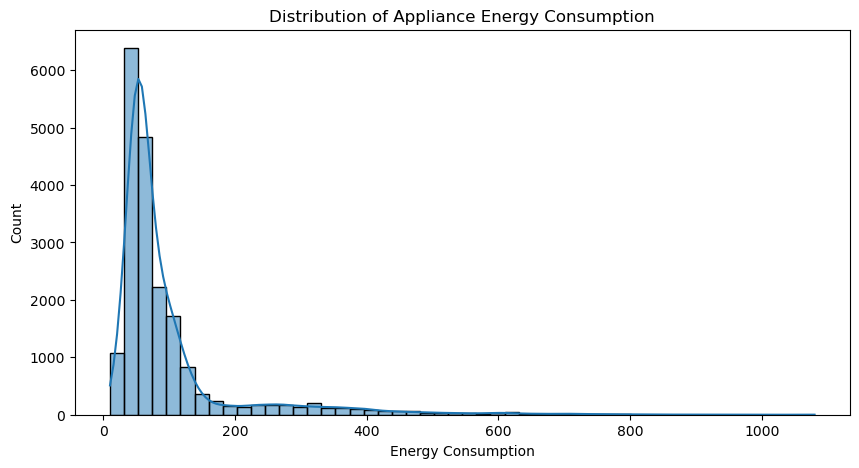

In [9]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Appliances'],
    bins=50,
    kde=True
)

plt.title("Distribution of Appliance Energy Consumption")
plt.xlabel("Energy Consumption")
plt.show()

### Insight

The target variable exhibits a right-skewed distribution, indicating that most observations correspond to relatively low appliance energy consumption while high-consumption events occur less frequently.

This suggests that extreme energy usage events are rare, which may increase prediction difficulty and contribute to higher errors for very large consumption values.

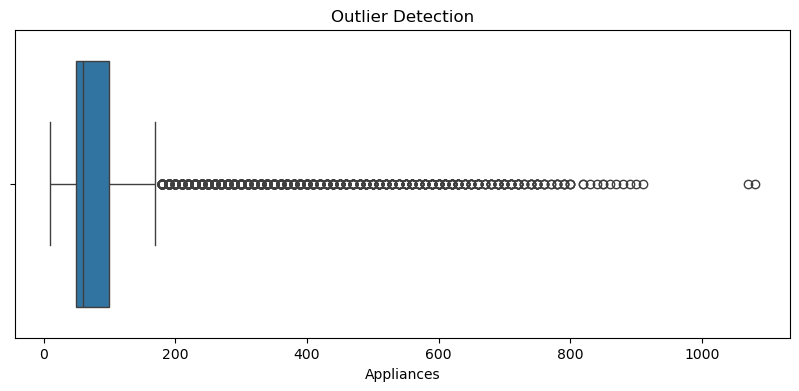

In [10]:
plt.figure(figsize=(10,4))

sns.boxplot(
    x=df['Appliances']
)

plt.title("Outlier Detection")
plt.show()

### Insight

The boxplot reveals a significant number of outliers in appliance energy consumption, with several observations exhibiting extremely high energy usage compared to the majority of households.

These outliers are expected in real-world energy datasets because appliance usage can vary considerably depending on occupant behavior and appliance operation patterns.

Since Random Forest is relatively robust to outliers, the observations were retained rather than removed to preserve valuable information about high-consumption events.

In [11]:
corr_target = df.corr(
    numeric_only=True
)['Appliances'].sort_values(
    ascending=False
)

corr_target

Appliances      1.000000
hour            0.216792
lights          0.197278
T2              0.120073
T6              0.117638
T_out           0.099155
Windspeed       0.087122
RH_1            0.086031
T3              0.085060
avg_temp        0.078247
T1              0.055447
T4              0.040281
T8              0.039572
RH_3            0.036292
T7              0.025801
T5              0.019760
is_weekend      0.017437
RH_4            0.016965
Tdewpoint       0.015357
T9              0.010010
RH_5            0.006955
weekday         0.003060
day             0.002366
Visibility      0.000230
rv2            -0.011145
rv1            -0.011145
month          -0.011606
Press_mm_hg    -0.034885
RH_9           -0.051462
RH_7           -0.055642
avg_humidity   -0.060228
RH_2           -0.060465
RH_6           -0.083178
RH_8           -0.094039
RH_out         -0.152282
Name: Appliances, dtype: float64

In [12]:
corr_target.head(15)

Appliances    1.000000
hour          0.216792
lights        0.197278
T2            0.120073
T6            0.117638
T_out         0.099155
Windspeed     0.087122
RH_1          0.086031
T3            0.085060
avg_temp      0.078247
T1            0.055447
T4            0.040281
T8            0.039572
RH_3          0.036292
T7            0.025801
Name: Appliances, dtype: float64

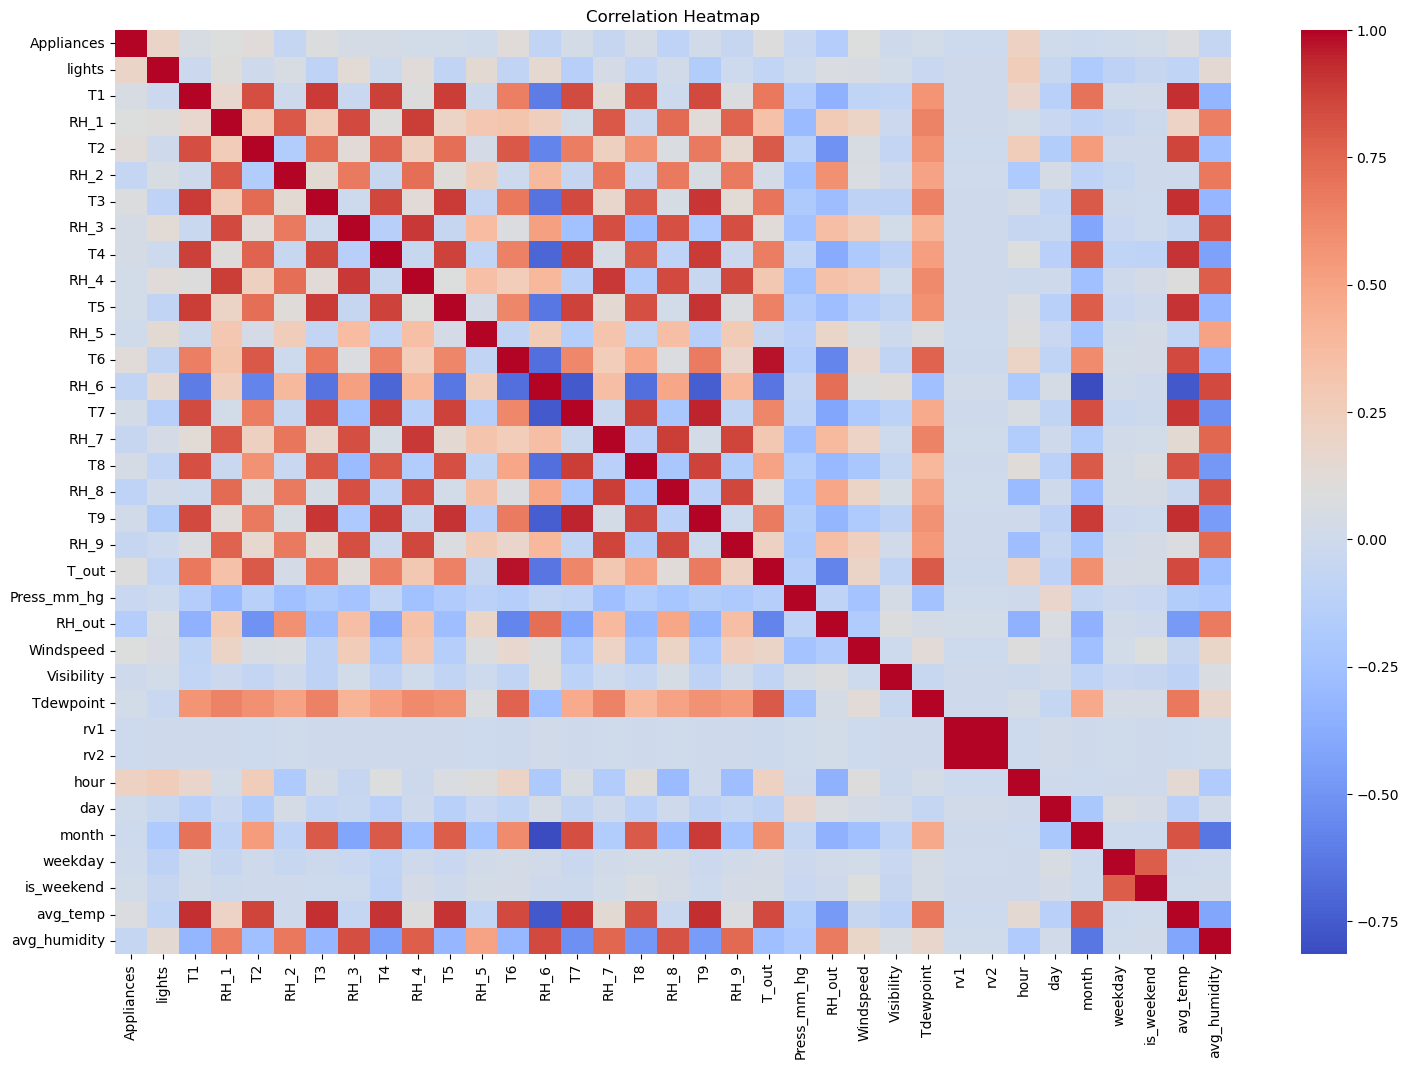

In [13]:
plt.figure(figsize=(18,12))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

### Insight

Several temperature and humidity sensors show moderate correlations, indicating similar environmental conditions across rooms. However, no single variable exhibits an extremely strong linear relationship with appliance energy consumption.

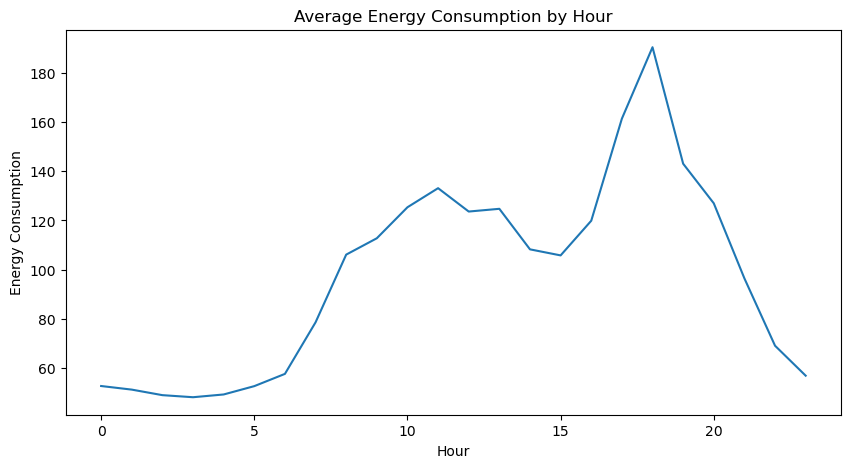

In [14]:
hourly_energy = df.groupby(
    'hour'
)['Appliances'].mean()

plt.figure(figsize=(10,5))

sns.lineplot(
    x=hourly_energy.index,
    y=hourly_energy.values
)

plt.title("Average Energy Consumption by Hour")
plt.xlabel("Hour")
plt.ylabel("Energy Consumption")
plt.show()

### Insight

Energy consumption varies across different hours of the day, suggesting that household activity patterns significantly influence appliance energy usage.

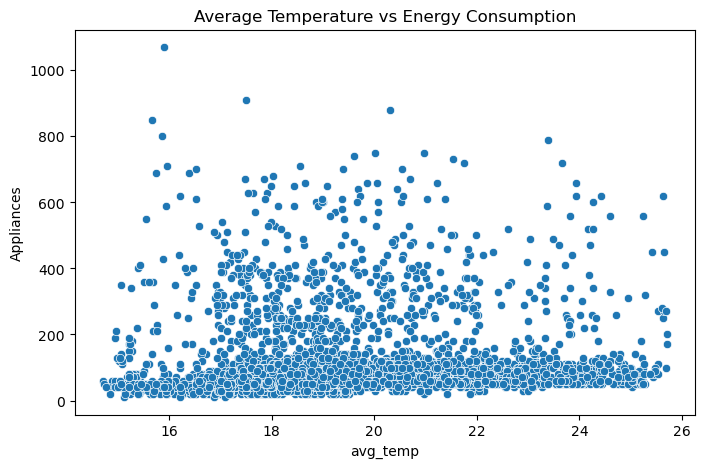

In [15]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df.sample(5000),
    x='avg_temp',
    y='Appliances'
)

plt.title("Average Temperature vs Energy Consumption")
plt.show()

### Insight

Both average temperature and average humidity exhibit weak direct linear relationships with appliance energy consumption. This indicates that appliance usage depends on multiple interacting factors rather than a single environmental variable.

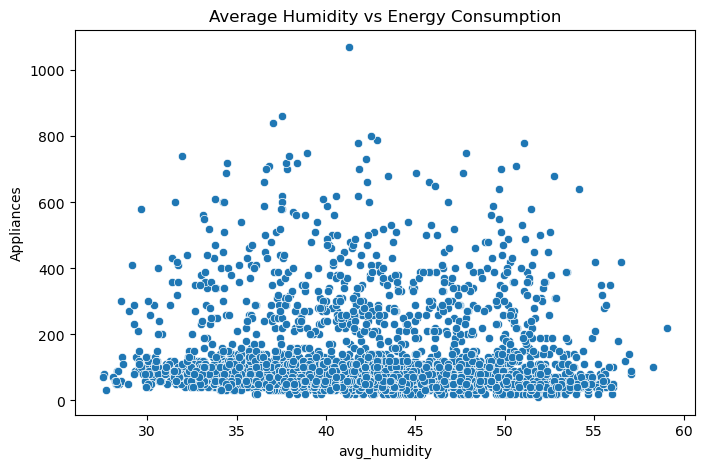

In [16]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df.sample(5000),
    x='avg_humidity',
    y='Appliances'
)

plt.title("Average Humidity vs Energy Consumption")
plt.show()

### Insight

The relationship between average humidity and appliance energy consumption appears weak and highly scattered.

While higher humidity levels are associated with some high-energy consumption observations, there is no strong linear trend. This suggests that humidity alone is not sufficient to explain appliance energy usage and that multiple environmental and behavioral factors influence consumption patterns.

These findings support the use of ensemble machine learning models such as Random Forest, which can capture complex non-linear relationships between variables.

In [18]:
df = df.drop('date', axis=1)

df.head()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,Tdewpoint,rv1,rv2,hour,day,month,weekday,is_weekend,avg_temp,avg_humidity
0,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,...,5.3,13.275433,13.275433,17,11,1,0,0,17.167407,50.910741
1,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,...,5.2,18.606195,18.606195,17,11,1,0,0,17.149630,50.827222
2,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,...,5.1,28.642668,28.642668,17,11,1,0,0,17.103704,50.628889
3,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,...,5.0,45.410390,45.410390,17,11,1,0,0,17.067037,50.574815
4,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,...,4.9,10.084097,10.084097,17,11,1,0,0,17.070741,50.732963


In [19]:
X = df.drop(
    'Appliances',
    axis=1
)

y = df['Appliances']

print(X.shape)
print(y.shape)

(19735, 34)
(19735,)


## Data Leakage Prevention

To ensure valid model evaluation:

- The target variable (Appliances) was excluded from feature engineering.
- A dedicated train-test split was used.
- Feature scaling was performed inside a Pipeline.
- Cross-validation was applied to assess model robustness.
- No future information was used during model training.

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(15788, 34)
(3947, 34)


In [21]:
numeric_features = X.columns.tolist()

numeric_features

['lights',
 'T1',
 'RH_1',
 'T2',
 'RH_2',
 'T3',
 'RH_3',
 'T4',
 'RH_4',
 'T5',
 'RH_5',
 'T6',
 'RH_6',
 'T7',
 'RH_7',
 'T8',
 'RH_8',
 'T9',
 'RH_9',
 'T_out',
 'Press_mm_hg',
 'RH_out',
 'Windspeed',
 'Visibility',
 'Tdewpoint',
 'rv1',
 'rv2',
 'hour',
 'day',
 'month',
 'weekday',
 'is_weekend',
 'avg_temp',
 'avg_humidity']

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numeric_features
        )
    ]
)

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)
from xgboost import XGBRegressor

models = {

    "Linear Regression":
        LinearRegression(),

    "Decision Tree":
        DecisionTreeRegressor(
            random_state=42
        ),

    "Random Forest":
        RandomForestRegressor(
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingRegressor(
            random_state=42
        ),

    "XGBoost":
        XGBRegressor(
            objective='reg:squarederror',
            random_state=42
        )
}

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

results = []

for name, model in models.items():

    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipe.fit(
        X_train,
        y_train
    )

    preds = pipe.predict(
        X_test
    )

    mae = mean_absolute_error(
        y_test,
        preds
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            preds
        )
    )

    r2 = r2_score(
        y_test,
        preds
    )

    results.append(
        [name, mae, rmse, r2]
    )

results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'MAE',
        'RMSE',
        'R2'
    ]
)

results_df.sort_values(
    'R2',
    ascending=False
)

,Model,MAE,RMSE,R2
2,Random Forest,31.882721,67.142302,0.549511
4,XGBoost,34.224331,67.950504,0.538600
3,Gradient Boosting,45.422989,83.208452,0.308126
1,Decision Tree,36.906511,90.295380,0.185252
0,Linear Regression,52.564438,91.103988,0.170594


In [25]:
from sklearn.model_selection import cross_val_score

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    (
        'model',
        RandomForestRegressor(
            random_state=42,
            n_jobs=-1
        )
    )
])

cv_scores = cross_val_score(
    rf_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

print("CV Scores:")
print(cv_scores)

print("\nMean CV R2:")
print(cv_scores.mean())

CV Scores:
[0.49368763 0.44753562 0.51821209 0.51608681 0.48866196]

Mean CV R2:
0.4928368225531831


In [26]:
param_grid = {

    'model__n_estimators':
        [200,300,500],

    'model__max_depth':
        [10,20,30,None],

    'model__min_samples_split':
        [2,5,10],

    'model__min_samples_leaf':
        [1,2,4],

    'model__max_features':
        ['sqrt','log2']
}

In [27]:
from sklearn.model_selection import RandomizedSearchCV

search = RandomizedSearchCV(

    estimator=rf_pipeline,

    param_distributions=param_grid,

    n_iter=20,

    cv=5,

    scoring='r2',

    random_state=42,

    n_jobs=-1,

    verbose=2
)

search.fit(
    X_train,
    y_train
)

print(search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
{'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': None}


In [28]:
final_model = search.best_estimator_

preds = final_model.predict(
    X_test
)

mae = mean_absolute_error(
    y_test,
    preds
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        preds
    )
)

r2 = r2_score(
    y_test,
    preds
)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 30.199940883371337
RMSE: 63.68816548130615
R2  : 0.5946691816585035


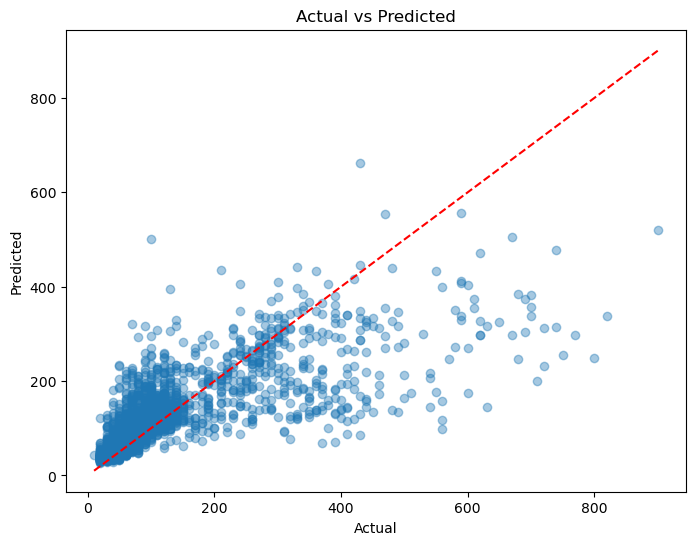

In [29]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    preds,
    alpha=0.4
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title(
    "Actual vs Predicted"
)

plt.show()

### Actual vs Predicted Interpretation

The scatter plot compares the actual appliance energy consumption values with the model predictions.

Most observations follow the diagonal trend line, indicating that the model captures the overall consumption pattern reasonably well.

However, for very high energy consumption values, the predictions tend to be lower than the actual values. This suggests that extreme energy usage events remain more difficult to predict accurately.

Overall, the Random Forest model demonstrates satisfactory predictive performance with an R² score of approximately 0.59.

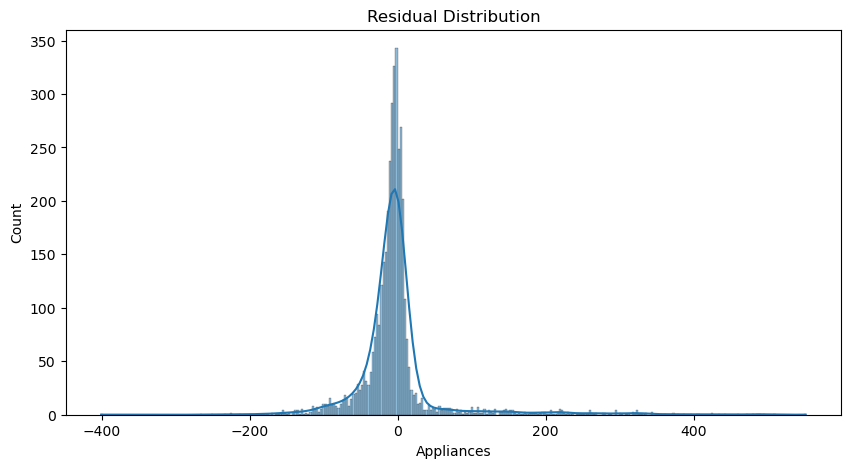

In [38]:
residuals = y_test - preds

plt.figure(figsize=(10,5))

sns.histplot(
    residuals,
    kde=True
)

plt.title(
    "Residual Distribution"
)

plt.show()

### Residual Analysis Interpretation

The residuals are centered around zero, suggesting that the model captures the overall relationship reasonably well. Larger errors are primarily observed for extreme energy consumption events, which are relatively rare in the dataset.

In [31]:
rf_model = final_model.named_steps[
    'model'
]

importance = pd.DataFrame({

    'Feature':
        X.columns,

    'Importance':
        rf_model.feature_importances_
})

importance = importance.sort_values(
    'Importance',
    ascending=False
)

importance.head(20)

,Feature,Importance
27,hour,0.078595
6,RH_3,0.039648
2,RH_1,0.038667
5,T3,0.038443
16,RH_8,0.036474
20,Press_mm_hg,0.036378
4,RH_2,0.036133
10,RH_5,0.036102
21,RH_out,0.033640
14,RH_7,0.033568


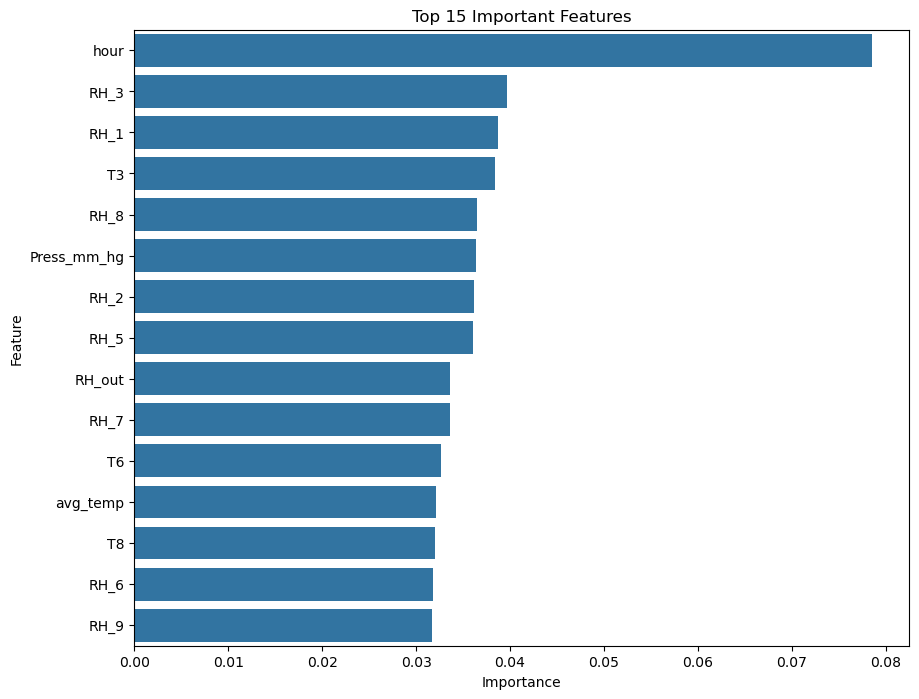

In [32]:
plt.figure(figsize=(10,8))

sns.barplot(

    data=importance.head(15),

    x='Importance',

    y='Feature'
)

plt.title(
    "Top 15 Important Features"
)

plt.show()

### Feature Importance Interpretation

Hour emerged as the most influential predictor, indicating that appliance energy usage is strongly driven by daily household activity patterns.

Humidity-related variables and environmental conditions also contribute significantly to energy consumption predictions.

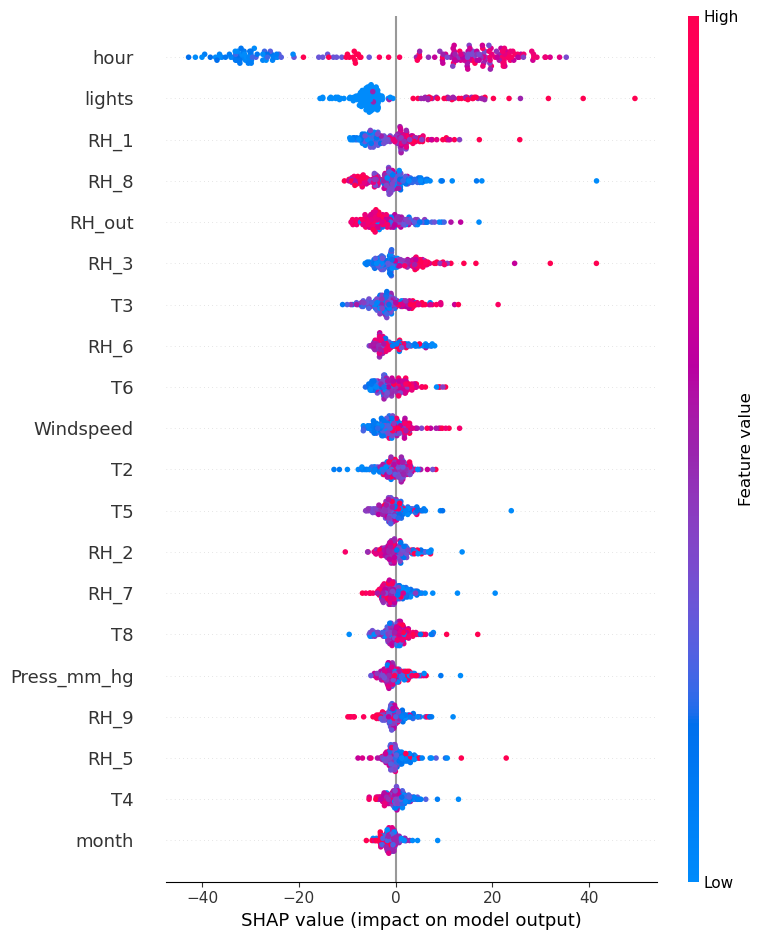

In [35]:
import shap

rf_model = final_model.named_steps['model']

X_processed = final_model.named_steps[
    'preprocessor'
].transform(X_test)

X_sample = X_processed[:200]

explainer = shap.TreeExplainer(
    rf_model
)

shap_values = explainer.shap_values(
    X_sample
)

shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=X.columns
)

## SHAP Interpretation

SHAP analysis was performed to understand how individual features influence appliance energy consumption predictions.

Key Findings:

- Hour emerged as the most influential feature, indicating that household activity patterns strongly affect energy demand.
- Lights was among the most important variables, suggesting a relationship between lighting usage and overall appliance consumption.
- Humidity-related features (RH_1, RH_8, RH_out, RH_3) contributed significantly to model predictions.
- Temperature and weather-related variables also influenced appliance energy usage, although to a lesser extent.

The SHAP results are consistent with the Random Forest feature importance analysis, increasing confidence in the model's interpretability.

In [37]:
import joblib

joblib.dump(
    final_model,
    "appliance_energy_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


# Conclusion

Random Forest was selected as the final model after evaluating multiple regression algorithms.

Final Results:

- MAE: 30.20
- RMSE: 63.69
- R²: 0.595

Key Findings:

- Hour of day is the strongest predictor.
- Humidity significantly affects energy consumption.
- Environmental conditions influence appliance energy usage.

Business Impact:

The model can support energy optimization, customer cost reduction, and improved energy demand planning.